# Processamento de Sinais I — Aula Prática 2
## Questão 3 — Espectro do áudio `handel.wav`

Objetivo: calcular o espectro do sinal de áudio e comentar os resultados.

## Importar bibliotecas e carregar a função de espectro

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from scipy.io import wavfile
from scipy import signal

def load_calculate_spectrum():
    notebook_path = Path('../tools/calculate_spectrum.ipynb')
    notebook = json.loads(notebook_path.read_text(encoding='utf-8'))

    namespace = {}
    for cell in notebook['cells']:
        if cell.get('cell_type') != 'code':
            continue

        source = ''.join(cell.get('source', []))
        exec(source, namespace)
        if 'calculate_spectrum' in namespace:
            return namespace['calculate_spectrum']

    raise RuntimeError('calculate_spectrum() nao encontrada em ../tools/calculate_spectrum.ipynb')

calculate_spectrum = load_calculate_spectrum()

plt.style.use('seaborn-v0_8-whitegrid')

def to_float_mono(data):
    data = np.asarray(data)
    if data.ndim > 1:
        data = data.mean(axis=1)
    if np.issubdtype(data.dtype, np.integer):
        data = data.astype(np.float64) / np.iinfo(data.dtype).max
    else:
        data = data.astype(np.float64)
    peak = np.max(np.abs(data))
    if peak > 1:
        data = data / peak
    return data


def show_audio(audio, rate, label):
    print(label)
    display(Audio(audio, rate=rate))


def plot_spectrum(signal_in, sampling_frequency, title, max_frequency=None):
    freqs, amps = calculate_spectrum(signal_in, sampling_frequency, single_sided=True)
    plt.figure(figsize=(12, 4))
    plt.plot(freqs, amps)
    if max_frequency is not None:
        plt.xlim(0, max_frequency)
    plt.title(title)
    plt.xlabel('Frequencia (Hz)')
    plt.ylabel('Amplitude')
    plt.tight_layout()
    return freqs, amps


## Ler o arquivo de áudio e visualizar seu espectro

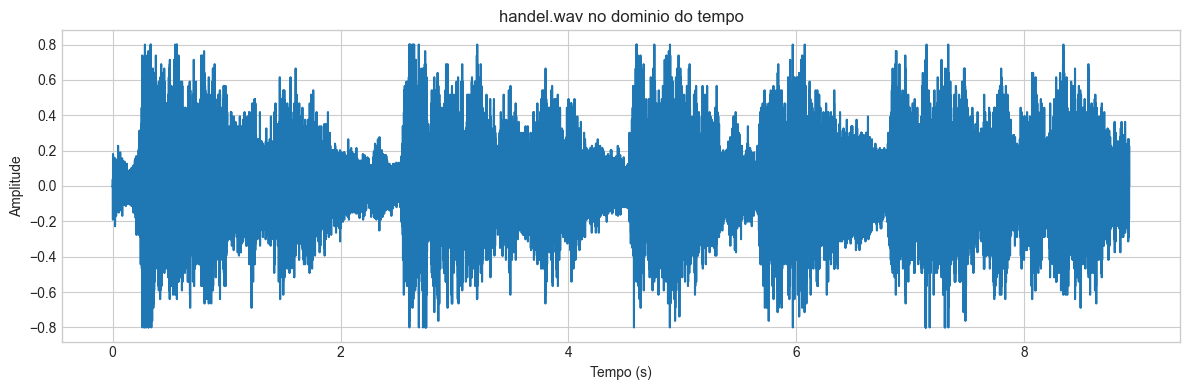

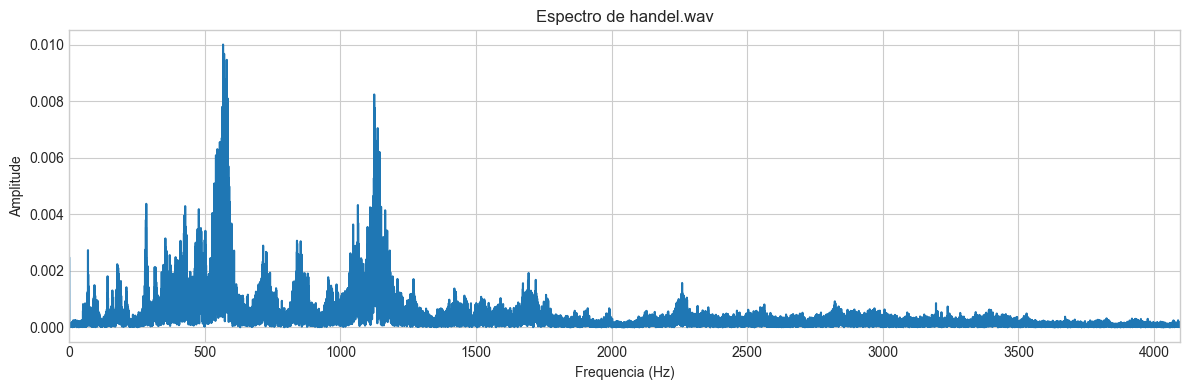

Audio original: handel.wav


In [2]:
fs, audio_int = wavfile.read('../data/handel.wav')
audio = to_float_mono(audio_int)

t = np.arange(len(audio)) / fs

plt.figure(figsize=(12, 4))
plt.plot(t, audio)
plt.title('handel.wav no dominio do tempo')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.tight_layout()

plot_spectrum(audio, fs, 'Espectro de handel.wav', max_frequency=fs / 2)
plt.show()

show_audio(audio, fs, 'Audio original: handel.wav')


## Comentários

O espectro de `handel.wav` é bem mais complexo do que o de senóides ou chirps isolados, porque o trecho musical contém várias componentes harmônicas simultâneas.

Em vez de um único pico ou de uma faixa contínua simples, aparecem múltiplos picos distribuídos em várias frequências, associados às notas e aos harmônicos presentes no áudio.